In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os
import copy as cp
import matplotlib.pyplot as plt
import numpy as np
import pickle
import pandas as pd
import zeus
import toml
from types import SimpleNamespace

import alfred.KSZ
import alfred.surveys
import alfred.utils as utils

from catwoman.shelter import Cat
from alfred.emulator import kemu
from alfred.parameters import *
from alfred.astrofit import *


parsing /Users/emcbride/Datasets/LoReLi/spectra/kSZ/LoReLi/nells30_v5 ...
6797 sims available


/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
plt.rcParams.update({
    "text.usetex": True,  # Use LaTeX for rendering
    'font.size': 13,
  #  "font.family": "serif",  # Use serif font
 #   "font.serif": ["Computer Modern Roman"],  # LaTeX's default font
})

# Introduction

This notebook contains all the code necessary to reproduce the plots of the paper

In [4]:
config = toml.load(f"{home_dir}/alfred/scripts/config_files/mcmc_config.toml")
config = SimpleNamespace(**config)

In [5]:
spectra_path = 'ps_ee'

In [6]:
sims = get_sims(f'spectra/kSZ/LoReLi/nells30_v5')
print(len(sims))

parsing /Users/emcbride/Datasets/LoReLi/spectra/kSZ/LoReLi/nells30_v5 ...
6797 sims available
6797


In [7]:
df

,fX,rHS,tau,Mmin,fesc
sim_n,,,,,
12104,-1.716699,0.8,3.186730,9.33,0.275
10630,-3.540608,0.0,3.487252,8.27,0.275
14596,-1.716699,0.0,3.601125,8.53,0.050
18223,-2.884190,0.6,3.697386,8.00,0.500
12090,-2.050181,0.4,3.186730,9.33,0.275
...,...,...,...,...,...
17154,-2.217012,0.4,3.589380,8.00,0.500
11452,-2.384260,0.0,3.396862,9.07,0.275
11425,-3.211549,0.6,3.396862,9.07,0.275


In [8]:
astro_pnames_formatted

['$L_X$',
 '$f_X$',
 '$\\tau{{\\mathrm{SF}}}$',
 '$M_{{\\mathrm{min}}}$',
 '$f_{{\\mathrm{esc}}}$']

In [9]:
xe_histories = np.load(f'{base_dir}/metadata/ion_histories_full.npz', allow_pickle=True)
xe_histories = xe_histories['arr_0'].item()
len(xe_histories)

9420

In [10]:
from scipy.integrate import cumulative_trapezoid

def xe2tau_plot(z):
        """
        Computes redshift evolution of the model's optical depth. This one is reversed for plotting purposes

        Parameters
        ----------
            z: (array of) float(s)
                Redshift range used to compute the optical depth.
        """
        cos = cosmology.FlatLambdaCDM(
            H0=ksz.h * 100, Tcmb0=ksz.T_cmb, Ob0=ksz.Ob_0, Om0=ksz.Om_0
        )
        z = np.sort(z)
        xe = np.sort(ksz.xe(z))[::-1]

        integ = constants.c.value * constants.sigma_T.value * ksz.nh * xe \
            / cos.H(z).si.value * (1+z)**2
        tofz = cumulative_trapezoid(integ, z, initial=0)

        return tofz

Completed 1/6797...
Completed 1001/6797...
Completed 2001/6797...
Completed 3001/6797...
Completed 4001/6797...
Completed 5001/6797...
Completed 6001/6797...


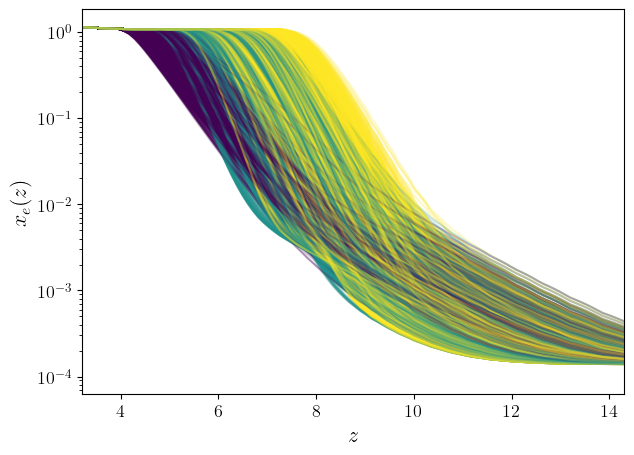

In [13]:
fig, ax = plt.subplots(sharex=True, figsize=(7,5))
fig.subplots_adjust(hspace=.00)

norm = matplotlib.colors.Normalize(vmin=df["fesc"].min(), vmax=df["fesc"].max())
cmap = plt.get_cmap('viridis')

for i, sn in enumerate(df.index):
    if i % 1000 == 0:
        # continue
        print(f"Completed {i+1}/{len(df)}...")


    sim = Cat(sn, skip_early=True,
                        base_dir=base_dir,
                        path_spectra=spectra_path,
                        LoReLi_format=True,
                        verbose=False)
    
    ksz = alfred.KSZ.KSZ_power(verbose=False, interpolate_xe=True, interpolate_Pee=True,
                helium=True, helium2=True, Pee_data=sim.Pee, xe_data=sim.xe, z_data=sim.z, k_data=sim.k,
                xemax=.97)
    
    color = cmap(norm(df.loc[sn]['fesc'])) 
    # if not ((Planck - 2.0 * Planck_err) <= ksz.tau <=(Planck + 2.0 * Planck_err)):
    #     color = 'darkblue'


    ax.semilogy(z3, ksz.xe(z3), color=color, alpha=.25)
    # ax[1].plot(z3, xe2tau_plot(z3), color=color, alpha=.25)
    
ax.set_xlim(3.2,14.3)

ax.set_xlabel(rf"$z$", fontsize=16)
ax.set_ylabel(rf"$x_e(z)$", fontsize=16)

fig.savefig('xe.pdf')

Completed 1/6797...
Completed 1001/6797...
Completed 2001/6797...
Completed 3001/6797...
Completed 4001/6797...
Completed 5001/6797...
Completed 6001/6797...


(0.0, 0.068)

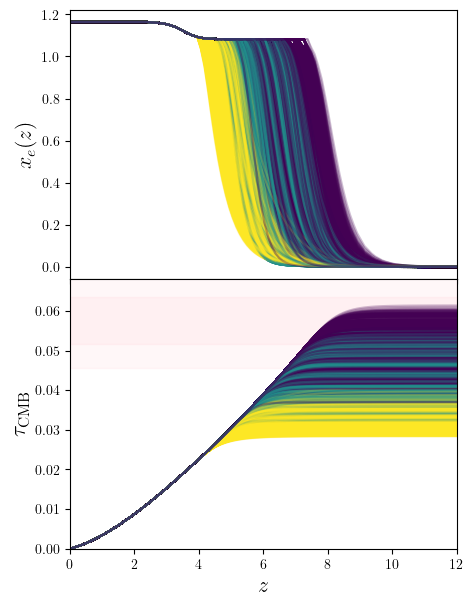

In [11]:
fig, ax = plt.subplots(2,1, sharex=True, figsize=(5,7))
fig.subplots_adjust(hspace=.00)


norm = matplotlib.colors.Normalize(vmin=df["fesc"].min(), vmax=df["fesc"].max())
cmap = plt.get_cmap('viridis_r')

ax[1].axhspan(Planck - Planck_err, Planck + Planck_err, color='lightpink', alpha=.1)
ax[1].axhspan(Planck - 2 * Planck_err, Planck + 2 * Planck_err, color='lightpink', alpha=.1)

for i, sn in enumerate(df.index):
    if i % 1000 == 0:
        print(f"Completed {i+1}/{len(df)}...")

    sim = Cat(sn, skip_early=True,
                        base_dir=base_dir,
                        path_spectra=spectra_path,
                        LoReLi_format=True,
                        verbose=False)
    
    ksz = alfred.KSZ.KSZ_power(verbose=False, interpolate_xe=True, interpolate_Pee=True,
                helium=True, helium2=True, Pee_data=sim.Pee, xe_data=sim.xe, z_data=sim.z, k_data=sim.k,
                xemax=.97)
    
    color = cmap(norm(df.loc[sn]['fesc'])) 
    # if not ((Planck - 2.0 * Planck_err) <= ksz.tau <=(Planck + 2.0 * Planck_err)):
    #     color = 'darkblue'


    ax[0].plot(z3, ksz.xe(z3), color=color, alpha=.25)
    ax[1].plot(z3, xe2tau_plot(z3), color=color, alpha=.25)

ax[0].set_ylabel(rf"$x_e(z)$", fontsize=16)

ax[1].set_xlabel(rf"$z$", fontsize=16)
ax[1].set_ylabel(rf"$\tau_{{\mathrm{{CMB}}}}$", fontsize=16)

ax[1].set_xlim(0,12)
ax[1].set_ylim(0,.068)

fig.savefig('xe_and_tau.png')

In [16]:
# priors = [(df[p].to_numpy().min(), df[p].to_numpy().max()) for p in df.columns]

norms = []
for p in priors:
    vmin = p[0]
    vmax = p[1]

    n = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    norms.append(n)

cmap = plt.get_cmap('viridis')

In [10]:
validation_sims = np.load(f'{base_dir}/emulators/setrandomseed3/validation_sims.npy', allow_pickle=True)

In [11]:
bad = np.load(f"{base_dir}/metadata/badsims_emulated.npy", allow_pickle=True)
good = np.load(f"{base_dir}/metadata/goodsims_emulated.npy", allow_pickle=True)

In [13]:
tspecs_mob

array([[0.68107125, 0.62410281, 0.54458108, ..., 0.08916873, 0.07786562,
        0.06738158],
       [0.48076554, 0.48115699, 0.41807766, ..., 0.09616384, 0.08609618,
        0.07620605],
       [0.63141201, 0.50930828, 0.46446338, ..., 0.09551726, 0.08289644,
        0.07144984],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(6797, 19))

In [37]:
survey_colors = ['#2ff3e0', '#cbfbf8', '#f8d210', '#fdf4aa', '#fa26a0', '#fdb9d8']

0
1
2
3
4
5


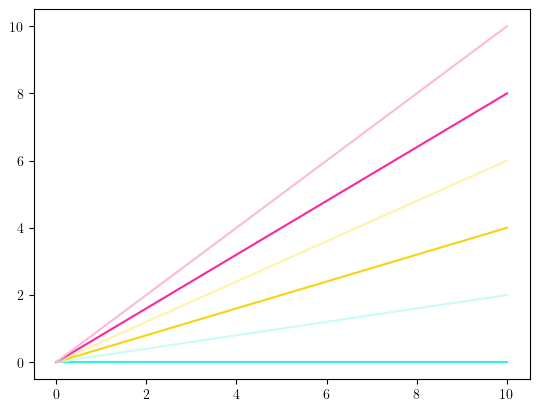

In [38]:
x = np.linspace(0,10)

for i, col in enumerate(survey_colors):
    print(i)
    plt.plot(x, i * .2 * x, color=col)

In [ ]:
fig, ax = plt.subplots(1,6, sharex=True, sharey=True, figsize=(12,5))
fig.subplots_adjust(wspace=0.0)

import alfred.utils as utils

mob = []
tspecs_mob  = np.zeros((len(validation_sims), len(ells[indices])))
especs_mob = np.zeros_like(tspecs_mob)

for i in range(5):
    print(f"Now on {i} run...")
    emu = summon_emu(f"setrandomseed3/emuv5.1_run{i}")
    mob.append(emu)

    tspecs  = np.zeros((len(validation_sims), len(ells[indices])))
    especs = np.zeros_like(tspecs)

    for si, sn in enumerate(validation_sims):
        # if si % 100 != 0:
        #     continue
        tspec = utils.spectra(sn)[indices]
        espec = emulator.kemu(df.loc[sn].to_numpy(), **emu)
        residual =  espec - tspec

        tspecs[si] = tspec
        especs[si] = espec

        if sn in bad:
            color = 'tomato'
        elif sn in good:
            color = 'navy'

        l = ax[i].plot(ells[indices], residual, color=color, alpha=.1)

        mob.append(emu)

print(f"On validation mob")
for si, sn in enumerate(validation_sims):
    if si % 1000 == 0:
        print(f"On i={si} sim...")
    #     continue
    tspec = utils.spectra(sn)[indices]
    espec = emulator.mechkemu(df.loc[sn].to_numpy(), mob)
    residual =  espec - tspec

    tspecs_mob[si] = tspec
    especs_mob[si] = espec

    if sn in bad:
        color = 'tomato'
    elif sn in good:
        color = 'navy'

    # print(residual)

    l = ax[-1].plot(ells[indices], residual, color=color, alpha=.1)
    
    # if lowbias[i]:
    #     color = 'navy'
    # elif not lowbias[i]:
    #     color = 'tomato'
    # l =ax[0].plot(ells[indices], tspec, color='navy', alpha=.1)
    # l =ax[0].plot(ells[indices], espec, color='tomato', alpha=.1)
ax[0].set_ylim(-.1,.1)
    

Now on 0 run...


/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Now on 1 run...


/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Now on 2 run...


...

Now on 3 run...


/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Now on 4 run...


/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


On validation mob
On i=0 sim...


On 0th sim
On 1000th sim
On 2000th sim
13925
0.87817
On 3000th sim
On 4000th sim
On 5000th sim
On 6000th sim


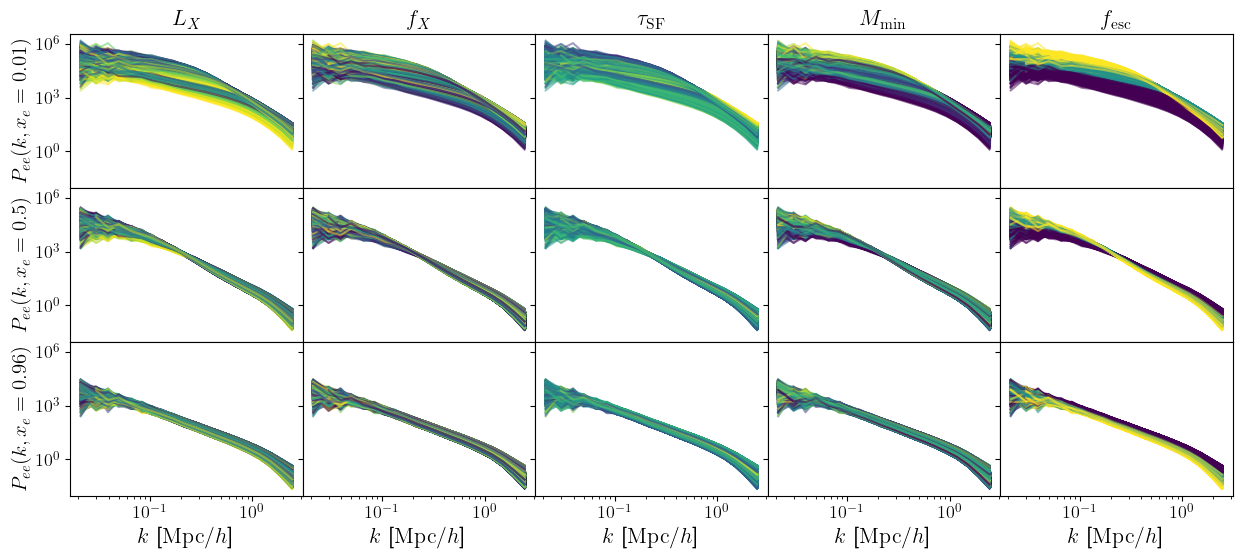

In [22]:
from scipy.interpolate import interp1d

xe_interp = np.array([.01, .5, .96]) # First I want to pick the ionisation fractions I want
# xe_interp = np.array([.01, .1, .5, .8, .96])

fig, axes = plt.subplots(xe_interp.size, 5, figsize=(15,6), sharex=True, sharey=True) # +1 for xe(z)
fig.subplots_adjust(wspace=0.0, hspace=0.0)

for i, sn in enumerate(df.index):
    if i % 1000 == 0:
       print(f'On {i}th sim')
        # continue
    sim = Cat(sn, skip_early=True,
            base_dir=base_dir,
            path_spectra=spectra_path,
            LoReLi_format=True,
            verbose=False)

    if sim.xe.max() < .97:
        print(sn)
        print(sim.xe.max())
        continue
    
    # Then I find the redshifts for these key ion fracs 
    z_xe = interp1d(sim.xe, sim.z)

    # Then I need to interpolate the Pee for these redshifts
    Pee_func = interp1d(sim.z, sim.Pee, axis=0)
    Pee = Pee_func(z_xe(xe_interp))

    for xi, xe in enumerate(xe_interp):
        ax = axes[xi]
        for pi, p in enumerate(df.loc[sn]):
            color = cmap(norms[pi](p))

            ax[pi].loglog(sim.k, Pee[xi], color=color, alpha=.5)

    # ax = axes[-1]
    # for pi, p in enumerate(df.loc[sn]):
    #     color = cmap(norm[pi](p))
    #     ax[pi].loglog(sim.z, sim.xe, color=color, alpha=.5)

for i, xei in enumerate(xe_interp):
    axes[i,0].set_ylabel(rf"$P_{{ee}}(k, x_{{e}}={xei})$", fontsize=15)

[axes[0,i].set_title(astro_pnames_formatted[i], fontsize=16) for i in range(len(df.columns))]

#[a.set_title() for a in axes[-1]]
[a.set_xlabel(r'$k$ [$\mathrm{{Mpc}}$/$h$]', fontsize=16) for a in axes[-1]]

fig.savefig('LoReLi_suite.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [19]:
from alfred.parameters import astro_pnames_formatted

astro_pnames_formatted

['$L_X$',
 '$f_X$',
 '$\\tau_{{\\mathrm{SF}}}$',
 '$M_{{\\mathrm{min}}}$',
 '$f_{{\\mathrm{esc}}}$']

$L_X$
$f_X$
$\tau_{{\mathrm{SF}}}$
$M_{{\mathrm{min}}}$
$f_{{\mathrm{esc}}}$


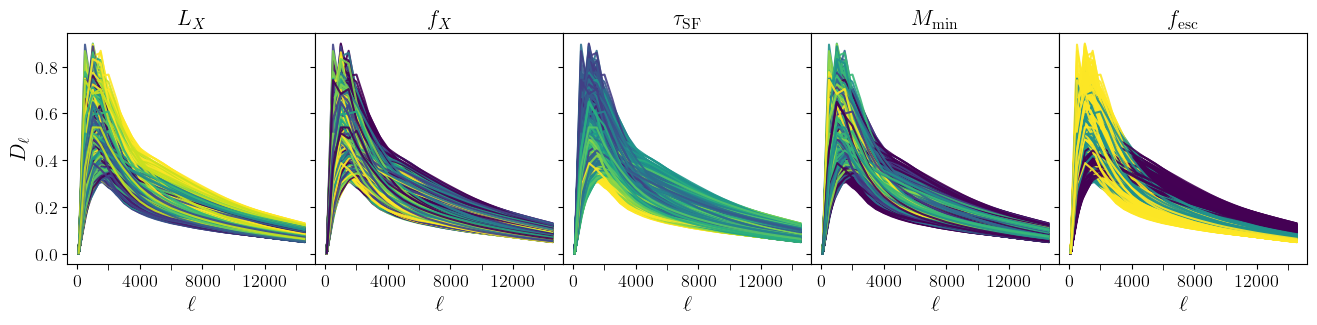

In [21]:
fig, ax = plt.subplots(1,5, sharex=True, sharey=True, figsize=(16,3))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

from matplotlib.ticker import AutoMinorLocator, MultipleLocator, MaxNLocator

# baddies = []
# failed_reion = []
for i, pname in enumerate(df.columns):
    vmin = df[pname].min()
    vmax = df[pname].max()

    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap('viridis')

    for j, sn in enumerate(df.index.to_list()):
        spectrum = utils.spectra(sn)

        pval = df.loc[sn][pname]
        ax[i].plot(ells, spectrum, color=cmap(norm(pval)), alpha=.9)
    
        # if np.isclose(df.loc[sn][pname], unique).any():
        #     label = f"Value: {df.loc[sn][pname]:.5f}"
        #     legend_handles.append(plt.Line2D([0], [0], color=cmap(norm(df.loc[sn][pname])), label=label))
  #  ax[i].axhline(.5, color='gray')
    # ax[i].legend(handles=legend_handles, title="Legend")
    print(astro_pnames_formatted[i])
    ax[i].set_title(astro_pnames_formatted[i], fontsize=16)
    ax[i].set_xlabel(rf"$\ell$", fontsize=16)

    ax[i].xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax[i].xaxis.set_minor_locator(AutoMinorLocator(2))  # 2 minor ticks between majors
    ax[i].tick_params(axis='x', which='minor', length=4, labelsize=10)

ax[0].set_ylabel(rf"$D_{{\ell}}$", fontsize=16)


# Add minor ticks to x-axis


fig.savefig('kSZ_spectra.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

### Fiducial simulation

In [ ]:
fig, ax = plt.subplots(2,5, sharex=True, sharey=True, figsize=(12,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

emu_paths = ['setrandomseed3/emuv5.1', 'reduced_dataset2/emuv5.0']
xfesc = np.linspace(*priors[4], 12)

N = len(xfesc)
cmap = matplotlib.cm.get_cmap('viridis')

# Generate N evenly spaced values in [0, 1]
colors = [cmap(i / (N - 1)) for i in range(N)]
for i, path in enumerate(emu_paths):
    for n in range(5):
        emu = summon_emu(f"{path}_run{n}", verbose=True)
        tspec = emulator.kemu(true_params, **emu)
        for it, t in enumerate(xfesc):
            params = cp.deepcopy(true_params)
            params[4] = t
            espec = emulator.kemu(params, **emu)

            label = ''
            if (i == 0) and (n==0):
                label = f"fesc={t:.3f}"
            ax[i,n].plot(ells[indices], tspec - espec, color=colors[it], label=label)

            ax[1,n].set_xlabel('ells')
            ax[0,0].set_ylabel('v5.1 style')
            ax[1,0].set_ylabel('v5.0 style')

fig.legend()


In [139]:
params = df.loc[config.sn].to_numpy()
truths = dict(zip(df.columns, params))

print(f"fitting simu{config.sn} with params:")
print(params)

fiducial = alfred.utils.spectra(config.sn)

fitting simu12958 with params:
[-1.71669877  0.          3.27712767  8.53        0.275     ]


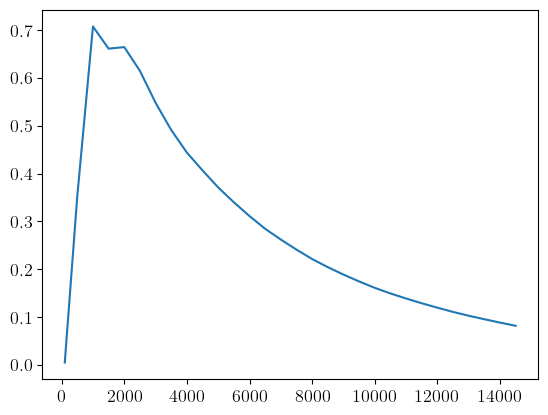

In [135]:
plt.plot(ells, fiducial)

### Surveys

We also need to assume some experimental noise configurations in order to generate our mock data. Here we plot the noise levels for each assumed survey setup.

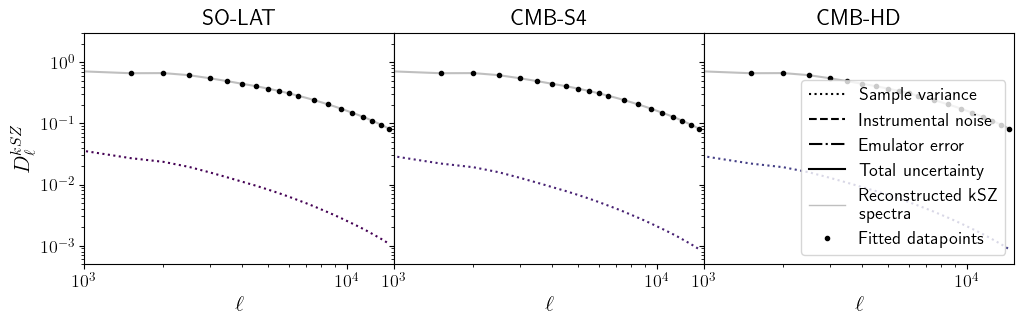

In [144]:
fig, ax = plt.subplots(1,3, sharex=True, sharey=True, figsize=(12,3))
fig.subplots_adjust(wspace=0.0)

from matplotlib.lines import Line2D

legend_lines = [
    Line2D([0], [0], color='black', linestyle=':', alpha=1.0, label='Sample variance'),
    Line2D([0], [0], color='black', linestyle='--', alpha=1.0, label='Instrumental noise'),
    Line2D([0], [0], color='black', linestyle='dashdot', alpha=1.0, label='Emulator error'),
    Line2D([0], [0], color='black', linestyle='-', alpha=1.0, label='Total uncertainty'),
    Line2D([0], [0], color='black', linestyle='-', alpha=.25, linewidth=1.0, label=f'Reconstructed kSZ \nspectra'),
    Line2D([0], [0], color='black', linestyle='', marker='.', alpha=1.0, linewidth=1.0, label=f'Fitted datapoints')  # alpha > 1 will be clipped to 1
]

samplevar = {'include_samplevar': False,
            'include_samplevar': False,
            'include_samplevar': False,}

for i, tele in enumerate(['SO-LAT', 'CMB-S4', 'CMB-HD']):

    ax[i].plot(ells, fiducial, color='black', alpha=.25)
    ax[i].plot(ells[indices], fiducial[indices], color='black', marker='.', ls='')

    cov = alfred.surveys.error_cov(ells, fiducial, alfred.surveys.telescopes[tele],
                                   include_emulator=False, include_noise=False, include_samplevar=True)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells, err,
                color=colors[i], ls=':')

    # cov = alfred.surveys.error_cov(ells, fiducial, alfred.surveys.telescopes[tele],
    #                                include_emulator=False, include_noise=True, include_samplevar=False)
    # err = np.sqrt(np.diag(cov))
    # ax[i].plot(ells, err, #label='noise' if i == 2 else None,
    #             color=colors[i], ls='--')

    # cov = alfred.surveys.error_cov(ells, fiducial, alfred.surveys.telescopes[tele],
    #                                include_emulator=True, include_noise=False, include_samplevar=False)
    # err = np.sqrt(np.diag(cov))
    # ax[i].plot(ells, err, #label='sample variance' if i == 2 else None,
    #             color=colors[i], ls='dashdot')

    # cov = alfred.surveys.error_cov(ells, fiducial, alfred.surveys.telescopes[tele],
    #                                include_emulator=True, include_noise=True, include_samplevar=True)
    # err = np.sqrt(np.diag(cov))
    # ax[i].plot(ells, err, #label='emulator error' if i == 2 else None,
    #             color=colors[i])
    
    ax[i].set_title(f'{tele}', fontsize=16)
    ax[i].set_xlabel(rf"$\ell$", fontsize=16)

ax[2].plot([],[])

#ax[0].set_ylabel(r'$\ell(\ell+1)C_\ell^{kSZ}/2\pi$')
ax[0].set_ylabel(r'$D_\ell^{kSZ}$', fontsize=16)
ax[0].set_xlim(1000)
ax[0].set_ylim(5e-4,3)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[2].legend(handles=legend_lines, loc='lower right')

fig.savefig('surveys.png', bbox_inches='tight', pad_inches=0.05, dpi=300)



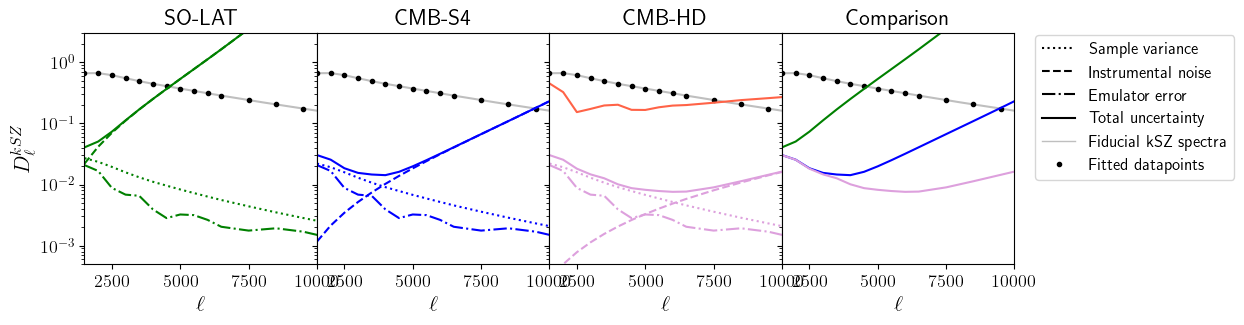

In [241]:
fig, ax = plt.subplots(1,4, sharex=True, sharey=True, figsize=(12,3))
fig.subplots_adjust(wspace=0.0)

from matplotlib.lines import Line2D

from alfred.parameters import colors

legend_lines = [
    Line2D([0], [0], color='black', linestyle=':', alpha=1.0, label='Sample variance'),
    Line2D([0], [0], color='black', linestyle='--', alpha=1.0, label='Instrumental noise'),
    Line2D([0], [0], color='black', linestyle='dashdot', alpha=1.0, label='Emulator error'),
    Line2D([0], [0], color='black', linestyle='-', alpha=1.0, label='Total uncertainty'),
    Line2D([0], [0], color='black', linestyle='-', alpha=.25, linewidth=1.0, label=f'Fiducial kSZ spectra'),
    Line2D([0], [0], color='black', linestyle='', marker='.', alpha=1.0, linewidth=1.0, label=f'Fitted datapoints')  # alpha > 1 will be clipped to 1
]

ells

ax[3].plot(ells, fiducial, color='black', alpha=.25)
ax[3].plot(ells[indices], fiducial[indices], color='black', marker='.', ls='')

for i, tele in enumerate(['SO-LAT', 'CMB-S4', 'CMB-HD']):

    ax[i].plot(ells, fiducial, color='black', alpha=.25)
    ax[i].plot(ells[indices], fiducial[indices], color='black', marker='.', ls='')

    cov = alfred.surveys.error_cov(ells[indices], fiducial[indices], alfred.surveys.telescopes[tele],
                                   include_emulator=False, include_noise=False, include_samplevar=True)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells[indices], err,
                color=colors[i], ls=':')

    cov = alfred.surveys.error_cov(ells[indices], fiducial[indices], alfred.surveys.telescopes[tele],
                                   include_emulator=False, include_noise=True, include_samplevar=False)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells[indices], err, #label='noise' if i == 2 else None,
                color=colors[i], ls='--')

    cov = alfred.surveys.error_cov(ells[indices], fiducial[indices], alfred.surveys.telescopes[tele],
                                   include_emulator=True, include_noise=False, include_samplevar=False)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells[indices], err, #label='sample variance' if i == 2 else None,
                color=colors[i], ls='dashdot')

    cov = alfred.surveys.error_cov(ells[indices], fiducial[indices], alfred.surveys.telescopes[tele],
                                   include_emulator=True, include_noise=True, include_samplevar=True)
    err = np.sqrt(np.diag(cov))
    ax[i].plot(ells[indices], err, #label='emulator error' if i == 2 else None,
                color=colors[i])
    
    ax[i].set_title(f'{tele}', fontsize=16)
    ax[i].set_xlabel(rf"$\ell$", fontsize=16)

    ax[3].plot(ells[indices], err, color=colors[i])

fg_residuals = np.genfromtxt(f"{base_dir}/metadata/cmbhd_fgs_coadded_noksz_Dl.txt").T
fg_residuals = np.interp(ells[indices], fg_residuals[0], fg_residuals[1])

ax[2].plot(ells[indices], fg_residuals, color='tomato')

ax[2].plot([],[])

ax[3].set_title(f'Comparison', fontsize=16)
ax[3].set_xlabel(rf"$\ell$", fontsize=16)

ax[0].set_xlim(1500, 10000)
#ax[0].set_ylabel(r'$\ell(\ell+1)C_\ell^{kSZ}/2\pi$')
ax[0].set_ylabel(r'$D_\ell^{kSZ}$', fontsize=16)
ax[0].set_ylim(5e-4,3)
# ax[0].set_xscale('log')
ax[0].set_yscale('log')
fig.legend(handles=legend_lines, loc='upper right', fontsize=12, bbox_to_anchor=(1.09, .9))

fig.savefig('surveys_comp.png', bbox_inches='tight', pad_inches=0.05, dpi=300)


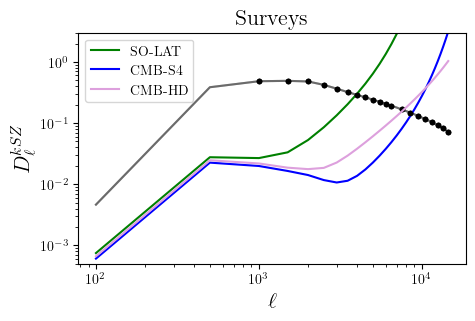

In [ ]:
fig, ax = plt.subplots(1,1, sharex=True, sharey=True, figsize=(5,3))
fig.subplots_adjust(wspace=0.0)

from matplotlib.lines import Line2D

legend_lines = [
    Line2D([0], [0], color='black', linestyle=':', alpha=1.0, label='Sample variance'),
    Line2D([0], [0], color='black', linestyle='--', alpha=1.0, label='Instrumental noise'),
    Line2D([0], [0], color='black', linestyle='dashdot', alpha=1.0, label='Emulator error'),
    Line2D([0], [0], color='black', linestyle='-', alpha=1.0, label='Total uncertainty'),
    Line2D([0], [0], color='black', linestyle='-', alpha=.25, linewidth=1.0, label=f'Reconstructed kSZ \nspectra'),
    Line2D([0], [0], color='black', linestyle='', marker='.', alpha=1.0, linewidth=1.0, label=f'Fitted datapoints')  # alpha > 1 will be clipped to 1
]

for i, tele in enumerate(['SO-LAT', 'CMB-S4', 'CMB-HD']):

    ax.plot(ells, fiducial, color='black', alpha=.25)
    ax.plot(ells[indices], fiducial[indices], color='black', marker='.', ls='')

    cov = alfred.surveys.error_cov(ells, fiducial, alfred.surveys.telescopes[tele],
                                   include_emulator=True, include_noise=True, include_samplevar=True)
    err = np.sqrt(np.diag(cov))
    ax.plot(ells, err, #label='emulator error' if i == 2 else None,
                color=colors[i], label=f"{tele}")
    
ax.set_title(f'Surveys', fontsize=16)
ax.set_xlabel(rf"$\ell$", fontsize=16)

#ax[0].set_ylabel(r'$\ell(\ell+1)C_\ell^{kSZ}/2\pi$')
ax.set_ylabel(r'$D_\ell^{kSZ}$', fontsize=16)
ax.set_ylim(5e-4,3)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()

fig.savefig('surveys.png')



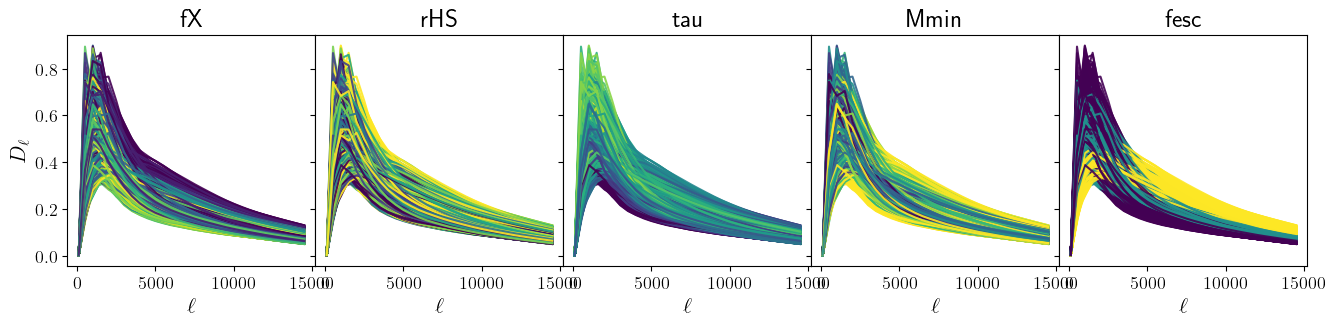

In [78]:
fig, ax = plt.subplots(1,5, sharex=True, sharey=True, figsize=(16,3))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

params_to_regress = astro_labels # currently just all

# baddies = []
# failed_reion = []
for i, pname in enumerate(df.columns):
    vmin = df[pname].min()
    vmax = df[pname].max()

    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap('viridis_r')

    for j, sn in enumerate(df.index.to_list()):
     #   if sn in failedrieon
        Dells = alfred.utils.spectra(sn, )

        pval = df.loc[sn][pname]
        ax[i].plot(ells, Dells, color=cmap(norm(pval)), alpha=.9)
    
        # if np.isclose(df.loc[sn][pname], unique).any():
        #     label = f"Value: {df.loc[sn][pname]:.5f}"
        #     legend_handles.append(plt.Line2D([0], [0], color=cmap(norm(df.loc[sn][pname])), label=label))
  #  ax[i].axhline(.5, color='gray')
    # ax[i].legend(handles=legend_handles, title="Legend")

    ax[i].set_title(df.columns.to_list()[i], fontsize=18)
    ax[i].set_xlabel(rf"$\ell$", fontsize=16)

ax[0].set_ylabel(rf"$D_{{\ell}}$", fontsize=16)

fig.savefig('spectra.png', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [9]:
df.sample(n=12)

,fX,rHS,tau,Mmin,fesc
sim_n,,,,,
18406,-2.050181,0.0,3.493123,8.53,0.500
12899,-3.374276,0.2,3.277128,8.53,0.275
18843,-3.053941,1.0,3.919256,8.27,0.500
10523,-2.217012,0.2,3.300617,9.60,0.275
10946,-3.540608,0.8,3.078747,9.33,0.275
17458,-2.384260,0.0,3.180871,9.07,0.500
10956,-3.211549,0.4,3.078747,9.33,0.275
12601,-3.053941,0.6,3.510746,9.33,0.275
18263,-1.716699,0.2,3.697386,8.00,0.500


### Ionisation Histories and the Optical Depth, $\tau$

In [288]:
xe_histories = np.load(f"{base_dir}/metadata/xe_histories_from_spectra.npz", allow_pickle=True)
xe_histories = xe_histories['arr_0'].item()

Still working, 0/4995 completed, on sim 12104...
Still working, 500/4995 completed, on sim 17496...
Still working, 1000/4995 completed, on sim 12232...
Still working, 1500/4995 completed, on sim 14090...
Still working, 2000/4995 completed, on sim 14219...
Still working, 2500/4995 completed, on sim 13051...
Still working, 3000/4995 completed, on sim 15095...
Still working, 3500/4995 completed, on sim 10631...
Still working, 4000/4995 completed, on sim 15085...
Still working, 4500/4995 completed, on sim 16683...


Text(0.5, 0, 'z')

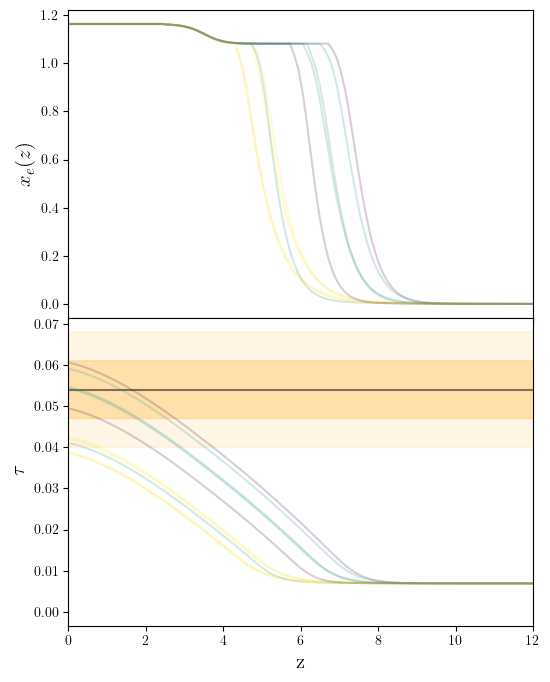

In [300]:
Planck = 0.054
Planck_err = 0.007

diff = 1.0
Planck_sn = 0

# sims_xe = []
# sims_failedreion = []
fig, ax = plt.subplots(2,1, sharex=True, figsize=(6,8))
fig.subplots_adjust(hspace=0.0)

norm = matplotlib.colors.Normalize(vmin=df["fesc"].min(), vmax=df["fesc"].max())
cmap = plt.get_cmap('viridis_r')

ax[1].fill_between(z3, Planck - 2.0 * Planck_err, Planck + 2.0 * Planck_err, color='orange', alpha=.1)
ax[1].fill_between(z3, Planck -  Planck_err, Planck + Planck_err, color='orange', alpha=.25)

ax[1].axhline(Planck, color='black', alpha=.5)

for i, sn in enumerate(df.index.to_list()):
    if i % 500 == 0:
        print(f'Still working, {i}/{len(df.index.to_list())} completed, on sim {sn}...')

        sim = Cat(sn, skip_early=True,
                                base_dir=base_dir,
                                path_spectra=spectra_path,
                                LoReLi_format=True,
                                verbose=False)
        
        if sim.xe.max() >= .97:

            ksz = KSZ.KSZ_power(verbose=False, interpolate_xe=True, interpolate_Pee=True,
                        helium=True, helium2=True, Pee_data=sim.Pee, xe_data=sim.xe, z_data=sim.z, k_data=sim.k,
                        xemax=.97)
            
            # KSZ.run_camb(force=True)
            # KSZ.init_reionisation_history()

            
            color = cmap(norm(df.loc[sn]['fesc']))

            fn = f'{base_dir}/spectra/kSZ/LoReLi/nells30_xion97/kSZ_LoReLi_simu{sn}.npz'

            if os.path.exists(fn):
                LoReLi = np.load(fn)

                ax[0].plot(z3, ksz.xe(z3), color=color, alpha=.2)
                ax[1].plot(z3, ksz.xe2tau(z3), color=color, alpha=.2)

ax[0].set_xlim(0,12)

ax[0].set_ylabel(r'$x_e(z)$', fontsize=15)
ax[1].set_ylabel(r"$\tau$", fontsize=15)
ax[1].set_xlabel('z', fontsize=15)


In [ ]:
fig.savefig('xion_tau.png')

In [ ]:
diff, Planck_sn

(np.float64(0.014014080573021143), '15060')

In [ ]:
sim = Cat(Planck_sn, skip_early=True,
                        base_dir=base_dir,
                        path_spectra=spectra_path,
                        path_redshifts=redshift_file,
                        LoReLi_format=True,
                        verbose=False)
    
ksz = KSZ.KSZ_power(verbose=False, interpolate_xe=True, interpolate_Pee=True,
                    helium_interp=True, Pee_data=sim.Pee, xe_data=sim.xe, z_data=sim.z, k_data=sim.k,
                    xemax=.97)
        

fn = f'{home_dir}/nells30_v2/kSZ_LoReLi_simu{Planck_sn}.npz'
LoReLi = np.load(fn)

print(f"tau:{ksz.tau:.3f}")
print(f"tau:{ksz.tau + diff:.3f}")

tau:0.040
tau:0.054


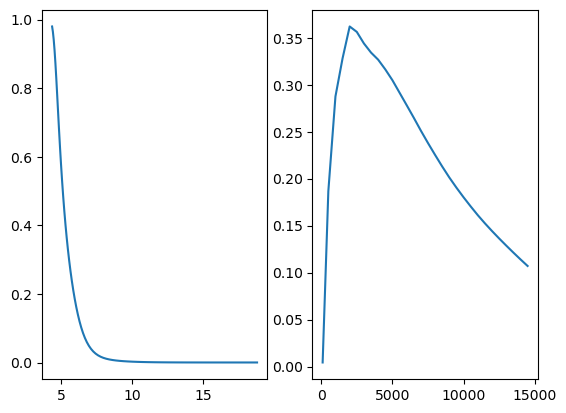

In [ ]:
fig, ax = plt.subplots(1,2)

ax[0].plot(sim.z, sim.xe)
ax[1].plot(LoReLi['ells'], LoReLi['kSZ'])

### Fiducial simulation

In [55]:
true_params = np.asarray([*df.loc[config.sn].to_numpy(), *whatthetau(df.loc[config.sn].to_numpy())])
true_params

array([-1.71669877,  0.        ,  3.27712767,  8.53      ,  0.275     ,
        0.05526446])

## Emulator performance and stability

Loading in our chosen emulator

In [14]:
nruns = 5
mob = []
for n in range(nruns):
    emu = summon_emu(f"{config.nndir}/emuv5.1_run{n}")
    mob.append(emu)

/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


On 1th emu...
On 2th emu...
On 3th emu...
On 4th emu...
On 5th emu...
On 5th emu...


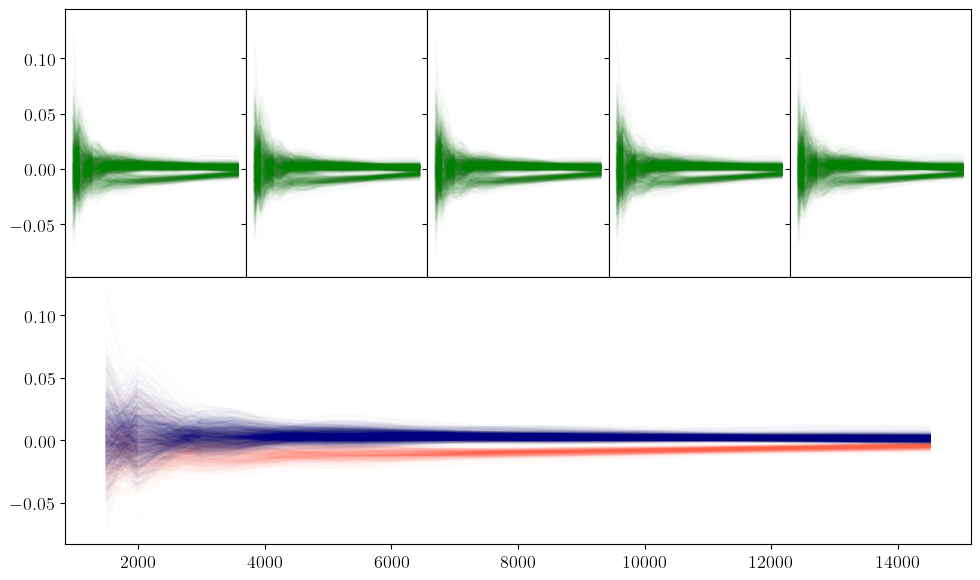

In [127]:
# fig, ax = plt.subplots(1,nruns+1, sharex=True, sharey=True, figsize=(25,5))
# fig.subplots_adjust(wspace=0.0, hspace=0.0)
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(10, 6))  # Adjust size as needed
gs = GridSpec(2, 5, height_ratios=[1, 1], hspace=0.0, wspace=0.0)  # 2 rows, 5 columns

# Top row: 5 separate axes
ax0 = fig.add_subplot(gs[0, 0])
axes_top = [ax0] + [fig.add_subplot(gs[0, i], sharex=ax0, sharey=ax0) for i in range(1, 5)]

# Bottom row: one axes spanning all columns
ax_bottom = fig.add_subplot(gs[1, :])

df_validation = df.loc[df.index.intersection(validation_sims)]

color_list = ['navy' if x in good else 'tomato' if x in bad else x for x in df_validation.index]

for i, emu in enumerate(mob):
    print(f"On {i+1}th emu...")
    espec = emulator.kemu(df_validation.to_numpy(), **emu)
    tspec = np.zeros_like(espec)
    for i_sim, sn in enumerate(df_validation.index):
        tspec[i_sim] = utils.spectra(sn)[indices]

    residuals = tspec - espec
    
    axes_top[i].plot(ells[indices], residuals.T, alpha=.01, color='green')

print(f"On {i+1}th emu...")
espec = emulator.mechkemu(df_validation.to_numpy(), mob)
tspec = np.zeros_like(espec)
for i_sim, sn in enumerate(df_validation.index):
    tspec[i_sim] = utils.spectra(sn)[indices]

residuals = tspec - espec

for i, sn in enumerate(df_validation.index):
    if sn in good:
        color = 'navy'
    if sn in bad:
        color = 'tomato'
        
    ax_bottom.plot(ells[indices], residuals[i], alpha=.01, color=color)

for ax in axes_top[1:]:
    ax.label_outer()  # hides x and y ticks except on edge axes

plt.tight_layout()
plt.show()


plotting 39 sims...


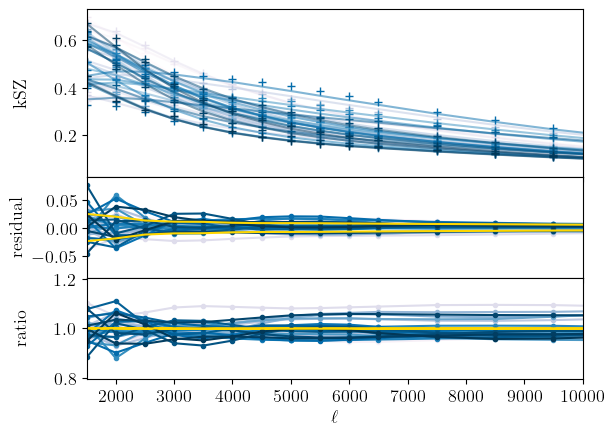

In [226]:
fig, ax = plt.subplots(3, 1, sharex=True, gridspec_kw={'height_ratios': [5, 3, 3]})
fig.subplots_adjust(wspace=0.0, hspace=0.0)

skipping = 35
sims_to_plot = validation_sims[::skipping]
print(f"plotting {len(sims_to_plot)} sims...")

N = len(sims_to_plot)
cmap = matplotlib.colormaps['PuBu']
    
# Generate N evenly spaced values in [0, 1]
ksz_colors = [cmap(i / (N - 1)) for i in range(N)]

data_ref = np.load(f"{base_dir}/inference/productionruns2_mechaemu/CMB-HD/noiseless/data.npz")
std = np.load(f"{base_dir}/emulators/{config.nndir}/ensemble_error_v5.1.npy")

for i, sn in enumerate(sims_to_plot):
    tspec = utils.spectra(sn)[indices]
    espec = emulator.mechkemu(df.loc[sn].to_numpy(), mob)

    ax[0].plot(ells[indices], tspec, marker='+', ls='', color=ksz_colors[i])
    ax[0].plot(ells[indices], espec, alpha=.5, color=ksz_colors[i])

    ax[1].plot(ells[indices], tspec - espec, marker='.', color=ksz_colors[i])
    ax[2].plot(ells[indices], espec / tspec, marker='.', color=ksz_colors[i])
    ax[2].plot(ells[indices], data_ref['Ashape'], color='gold')

ax[1].plot(ells[indices], -std, color='gold')
ax[1].plot(ells[indices], std, color='gold')

# a1.plot(x, y)
# a2.plot(x, y)

ax[0].set_xlim(1500,10000)
ax[1].set_ylim(-.09, .09)
ax[2].set_ylim(.795, 1.205)

ax[2].set_xlabel(rf"$\ell$")

ax[0].set_ylabel(rf"$\mathrm{{kSZ}}$")
ax[1].set_ylabel(rf"$\mathrm{{residual}}$")
ax[2].set_ylabel(rf"$\mathrm{{ratio}}$")

ax[0].yaxis.set_label_coords(-0.115, 0.5) 
ax[2].yaxis.set_label_coords(-0.115, 0.5) 

fig.savefig("NNemulator.png", bbox_inches='tight', pad_inches=0.05, dpi=300)

In [58]:
def degeneracy(Mmin, slope=priors2d['m'], intercept=priors2d['b_below']):
    return priors2d['m'] * Mmin + priors2d['b_below']

xMmin = np.linspace(*priors[3],10)
xtau = degeneracy(xMmin)

/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_76328/910443812.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('viridis')
/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_76328/910443812.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` o

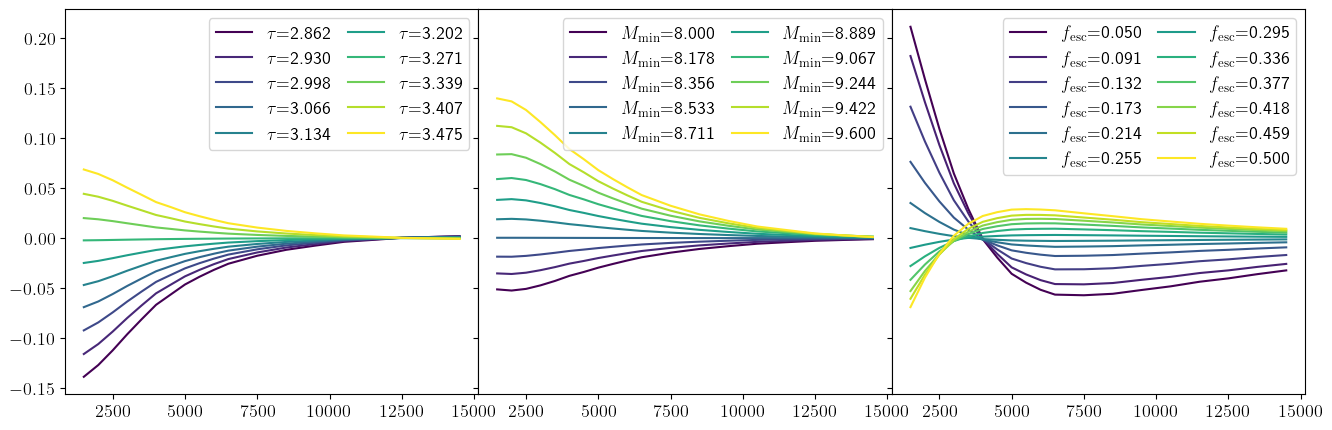

In [79]:
fig, ax = plt.subplots(1,3, sharex=True, sharey=True, figsize=(16,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

params_x = [xtau[::-1], xMmin, xfesc]

for i_param, prange in enumerate(params_x):
    N = len(prange)
    cmap = matplotlib.cm.get_cmap('viridis')
    
    # Generate N evenly spaced values in [0, 1]
    colors = [cmap(i / (N - 1)) for i in range(N)]
    for it, t in enumerate(prange):
        params = cp.deepcopy(true_params[:-1])
        params[2+i_param] = t
        espec = emulator.mechkemu(params, mob)
        label = rf"{astro_pnames_formatted[2+i_param]}$=${t:.3f}"
        ax[i_param].plot(ells[indices], tspec - espec, color=colors[it], label=label)
        ax[i_param].legend(ncol=2, columnspacing=1.0, fontsize=13)

fig.savefig('x_vs_dkSZ.png', bbox_inches='tight', pad_inches=0.05, dpi=300)

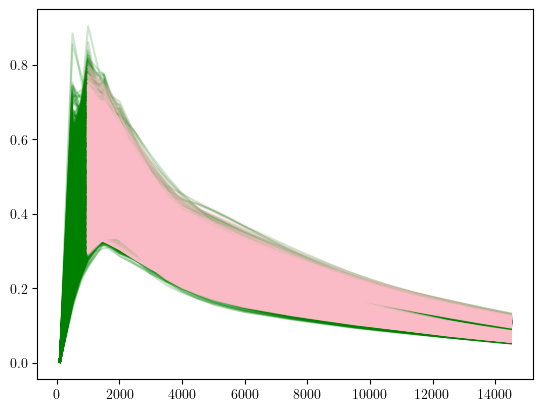

In [236]:
data = np.zeros((signal.shape[0], 30))

for i, sn in enumerate(spectra):
    data[i] = spectra[sn]

l = plt.plot(ells, data.T, color='green', alpha=.2)
l = plt.plot(ells[indices], signal.T, color='pink', alpha=.2)

In [1]:
fig, ax = plt.subplots(3,len(df.columns.to_list()[2:]), sharex='col', sharey='row', figsize=(20,10))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

norm = matplotlib.colors.Normalize(vmin=df["rHS"].min(), vmax=df["rHS"].max())
cmap = plt.get_cmap('viridis_r')

samples = draws(1000)

params = df.to_numpy()
data = np.zeros((len(df), len(ells[indices])))
for i_sim, sn in enumerate(df.index):
    data[i_sim] = utils.spectra(sn)[indices]
    
signal = emulator.kemu(samples, mob)
color = cmap(norm(params[-1]))

skwargs = {'marker':'.', 
           's':25,
           'alpha':.5,
           'color':color,
           'rasterized': True}

for i, pname in enumerate(df.columns.to_list()[2:]):
    skwargs['marker'] = '+'
    skwargs['alpha'] = .04
    skwargs['color'] = 'black'

    ax[0,i].scatter(params[:,i], np.max(data, axis=1), **skwargs)
    ax[1,i].scatter(params[:,i], ells[indices][np.argmax(data[:,1:], axis=1)], **skwargs)
    ax[2,i].scatter(params[:,i], data[:,4], **skwargs)

    skwargs['color'] = cmap(norms[i](samples[:,i]))
    skwargs['marker'] = '.'
    skwargs['alpha'] = .5

    ax[0,i].scatter(samples[:,i], np.max(signal, axis=1), **skwargs)
    ax[1,i].scatter(samples[:,i], ells[indices][np.argmax(signal, axis=1)], **skwargs)
    ax[2,i].scatter(samples[:,i],  signal[:,4], **skwargs)

    ax[2,i].set_xlabel(astro_pnames_formatted[2+i], fontsize=25)

ax[0, 0].set_ylabel(r"$D_{\ell, \mathrm{max}}$", fontsize=30, rotation=0, labelpad=50)
ax[1, 0].set_ylabel(r"$\ell_{\mathrm{max}}$", fontsize=30, rotation=0, labelpad=50)
ax[2, 0].set_ylabel(r"$D_{\ell=3000}$", fontsize=30, rotation=0, labelpad=50)

ax[1,0].set_ylim(1000, 3000)

fig.savefig('trends.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)



NameError: name 'plt' is not defined

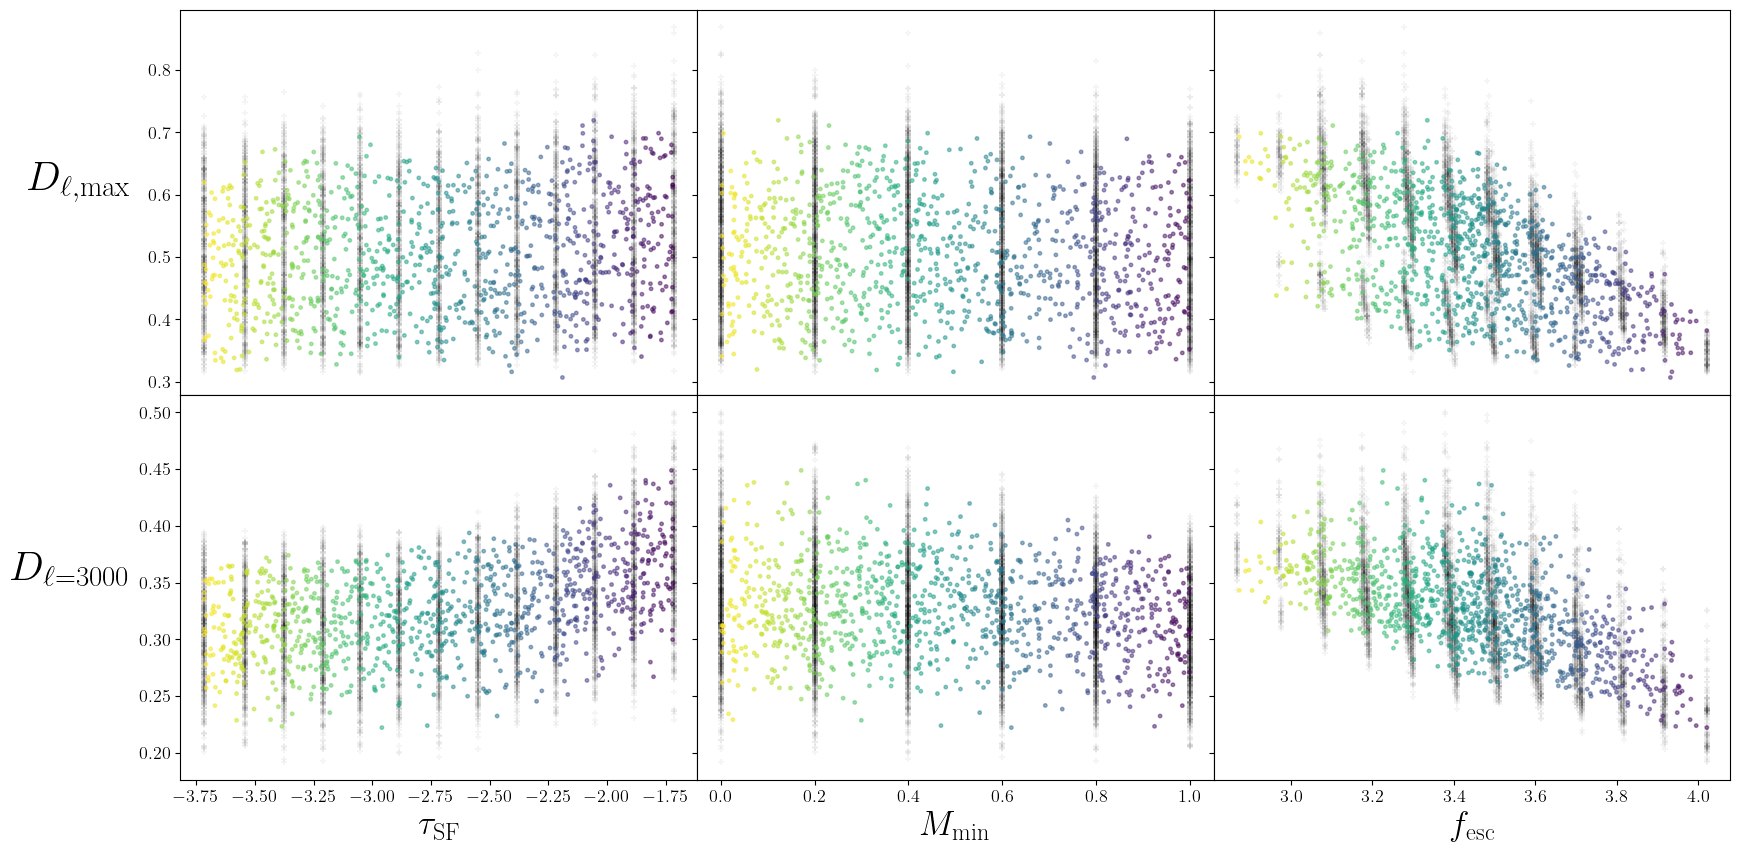

In [23]:
fig, ax = plt.subplots(2,len(df.columns.to_list()[2:]), sharex='col', sharey='row', figsize=(20,10))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

norm = matplotlib.colors.Normalize(vmin=df["rHS"].min(), vmax=df["rHS"].max())
cmap = plt.get_cmap('viridis_r')

samples = draws(1000)

params = df.to_numpy()
data = np.zeros((len(df), len(ells[indices])))
for i_sim, sn in enumerate(df.index):
    data[i_sim] = utils.spectra(sn)[indices]
    
signal = emulator.kemu(samples, mob)
color = cmap(norm(params[-1]))

skwargs = {'marker':'.', 
           's':25,
           'alpha':.5,
           'color':color,
           'rasterized': True}

for i, pname in enumerate(df.columns.to_list()[2:]):
    skwargs['marker'] = '+'
    skwargs['alpha'] = .04
    skwargs['color'] = 'black'

    ax[0,i].scatter(params[:,i], np.max(data, axis=1), **skwargs)
    # ax[1,i].scatter(params[:,i], ells[indices][np.argmax(data[:,1:], axis=1)], **skwargs)
    ax[1,i].scatter(params[:,i], data[:,4], **skwargs)

    skwargs['color'] = cmap(norms[i](samples[:,i]))
    skwargs['marker'] = '.'
    skwargs['alpha'] = .5

    ax[0,i].scatter(samples[:,i], np.max(signal, axis=1), **skwargs)
    # ax[1,i].scatter(samples[:,i], ells[indices][np.argmax(signal, axis=1)], **skwargs)
    ax[1,i].scatter(samples[:,i],  signal[:,4], **skwargs)

    ax[1,i].set_xlabel(astro_pnames_formatted[2+i], fontsize=25)

ax[0, 0].set_ylabel(r"$D_{\ell, \mathrm{max}}$", fontsize=30, rotation=0, labelpad=50)
# ax[1, 0].set_ylabel(r"$\ell_{\mathrm{max}}$", fontsize=30, rotation=0, labelpad=50)
ax[1, 0].set_ylabel(r"$D_{\ell=3000}$", fontsize=30, rotation=0, labelpad=50)

# ax[1,0].set_ylim(1000, 3000)

fig.savefig('trends2.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)



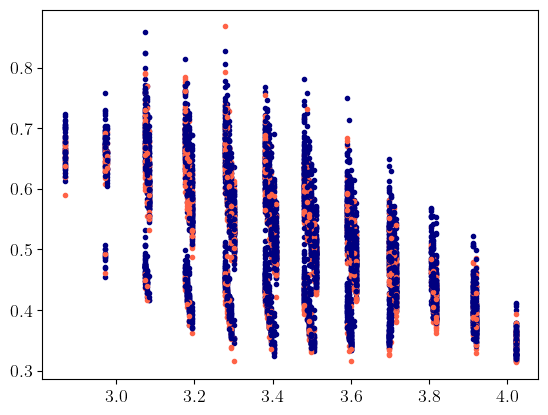

In [96]:
fig, ax = plt.subplots()

for sn in df.index:
    tau_i = df.loc[sn]['tau']
    spec = np.max(utils.spectra(sn)[indices])

    if sn in good:
        color = 'navy'
    if sn in bad:
        color = 'tomato'
    ax.scatter(tau_i, spec, marker='.', color=color)

## Appendix Plots

### Cuts
Because we don't have an infinite sized box we have to make some cuts.

#### cuts to kmin

In [ ]:
kmin_cuts = np.load(f"{base_dir}/cuts/kmin_cutoffs.npz")
kmin_cuts

NpzFile '/Users/emcbride/Datasets/LoReLi/cuts/kmin_cutoffs.npz' with keys: cuts, Dells

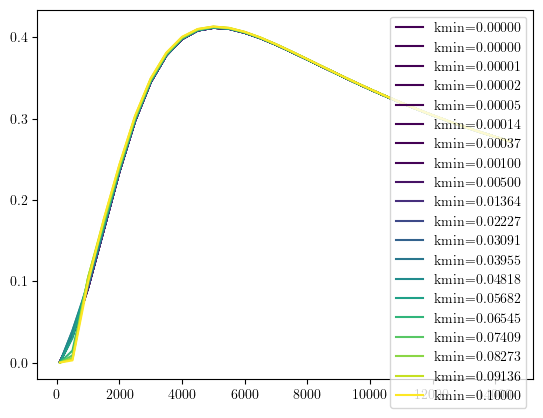

In [ ]:
Dells = kmin_cuts['Dells']
kmin = kmin_cuts['cuts']

norm = matplotlib.colors.Normalize(vmin=kmin.min(), vmax=kmin.max())
cmap = plt.get_cmap('viridis')

for i, km in enumerate(kmin):
    plt.plot(ells, Dells[i], color=cmap(norm(km)), label=f"kmin={km:.5f}")

plt.legend()

In [ ]:
kmax_cuts = np.load(f"{base_dir}/cuts/kmax_cutoffs.npz")
kmax_cuts

NpzFile '/Users/emcbride/Datasets/LoReLi/cuts/kmax_cutoffs.npz' with keys: cuts, Dells

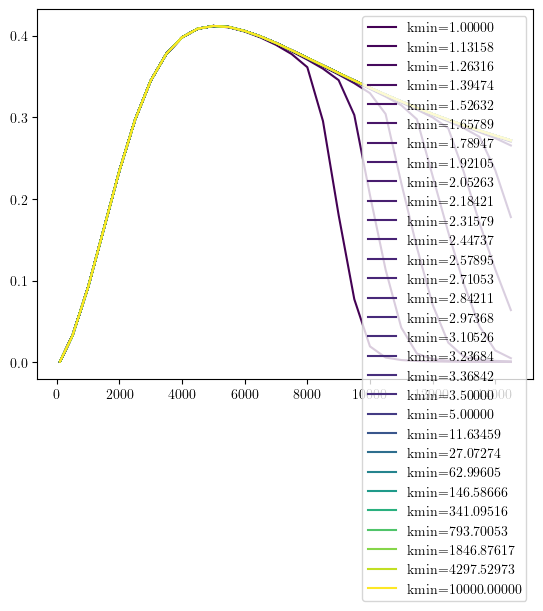

In [ ]:
Dells = kmax_cuts['Dells']
kmax = kmax_cuts['cuts']

norm = matplotlib.colors.LogNorm(vmin=kmax.min(), vmax=kmax.max())
cmap = plt.get_cmap('viridis')

for i, km in enumerate(kmax):
    plt.plot(ells, Dells[i], color=cmap(norm(km)), label=f"kmin={km:.5f}")

plt.legend()

In [ ]:
xemin_cuts = np.load(f"{base_dir}/cuts/xemin_cutoffs.npz")
xemin_cuts

NpzFile '/Users/emcbride/Datasets/LoReLi/cuts/xemin_cutoffs.npz' with keys: cuts, Dells

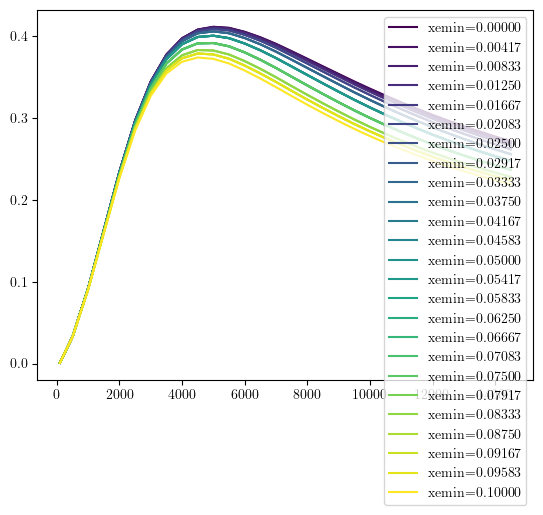

In [ ]:
Dells = xemin_cuts['Dells']
xemin = xemin_cuts['cuts']



norm = matplotlib.colors.Normalize(vmin=xemin.min(), vmax=xemin.max())
cmap = plt.get_cmap('viridis')

for i, xm in enumerate(xemin):
    plt.plot(ells, Dells[i], color=cmap(norm(xm)), label=f"xemin={xm:.5f}")

plt.legend()

In [ ]:
xemax_cuts = np.load(f"{base_dir}/cuts/xemax_cutoffs.npz")
xemax_cuts

NpzFile '/Users/emcbride/Datasets/LoReLi/cuts/xemax_cutoffs.npz' with keys: cuts, Dells

In [ ]:
1e-3 / xe_recomb

5.88235294117647

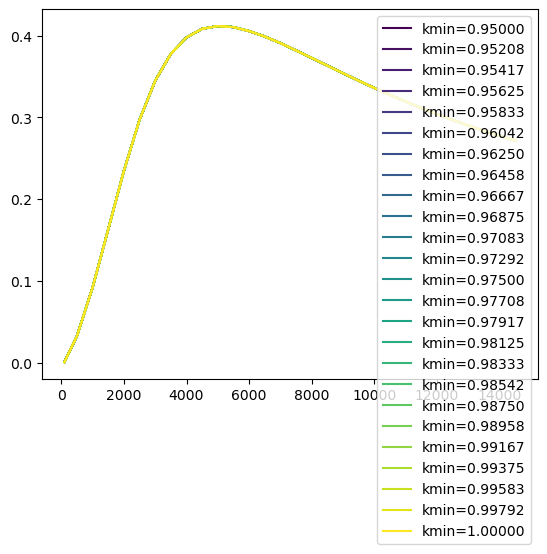

In [ ]:
Dells = xemax_cuts['Dells']
xemax = xemax_cuts['cuts']

norm = matplotlib.colors.Normalize(vmin=xemax.min(), vmax=xemax.max())
cmap = plt.get_cmap('viridis')

for i, xm in enumerate(xemax):
    plt.plot(ells, Dells[i], color=cmap(norm(xm)), label=f"kmin={xm:.5f}")

plt.legend()

#### Numerical Integration

In [ ]:
deltas = np.load(f"{base_dir}/cuts/dz_cutoffs.npz")
deltas

NpzFile '/Users/emcbride/Datasets/LoReLi/cuts/dz_cutoffs.npz' with keys: cuts, Dells

In [ ]:
deltas['cuts']

array([0.15 , 0.075, 0.03 ])

(4.0, 10.0)

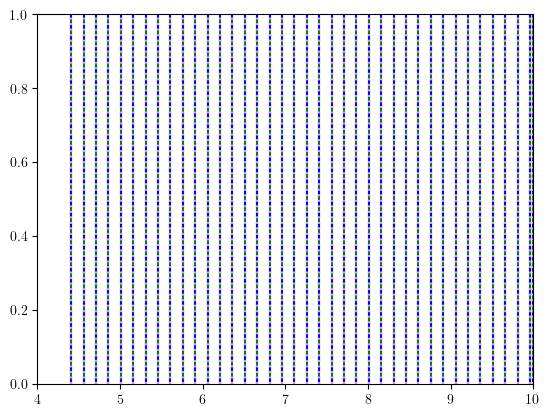

In [ ]:
Dells = deltas['Dells']
delta = deltas['deltas']

lss = ['-', '--', ':']
norm = matplotlib.colors.Normalize(vmin=delta.min(), vmax=delta.max())
cmap = plt.get_cmap('viridis')

fig, ax = plt.subplots()

for i, zinteg in enumerate(deltas['zintegs']):
    [ax.axvline(zi, color=colors[i], ls=lss[i]) for zi in zinteg]

ax.set_xlim(4.0, 10)

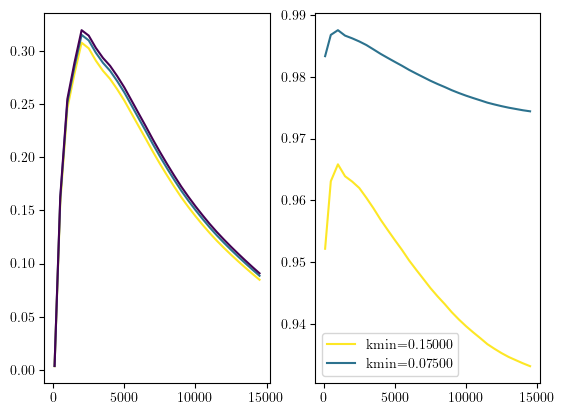

In [ ]:
Dells = deltas['Dells']
delta = deltas['cuts']

norm = matplotlib.colors.Normalize(vmin=delta.min(), vmax=delta.max())
cmap = plt.get_cmap('viridis')

fig, ax = plt.subplots(1,2)

for i, d in enumerate(delta):
    ax[0].plot(ells, Dells[i], color=cmap(norm(d)), label=f"kmin={d:.5f}")
    
    if i < 2:
        ax[1].plot(ells, Dells[i] / Dells[-1], color=cmap(norm(d)), label=f"kmin={d:.5f}")

plt.legend()

In [ ]:
zintegs

[array([ 0.1       ,  0.12669861,  0.16052539,  0.20338344,  0.257684  ,
         0.32648206,  0.41364825,  0.5240866 ,  0.66401045,  0.84129204,
         1.06590536,  1.35048732,  1.71104872,  2.16787502,  2.7466676 ,
         3.47998979,  4.40909884,  4.55909884,  4.70909884,  4.85909884,
         5.00909884,  5.15909884,  5.30909884,  5.45909884,  5.60909884,
         5.75909884,  5.90909884,  6.05909884,  6.20909884,  6.35909884,
         6.50909884,  6.65909884,  6.80909884,  6.95909884,  7.10909884,
         7.25909884,  7.40909884,  7.55909884,  7.70909884,  7.85909884,
         8.00909884,  8.15909884,  8.30909884,  8.45909884,  8.60909884,
         8.75909884,  8.90909884,  9.05909884,  9.20909884,  9.35909884,
         9.50909884,  9.65909884,  9.80909884,  9.95909884, 10.        ,
        10.5       , 11.        , 11.5       , 12.        , 12.5       ,
        13.        , 13.5       , 14.        , 14.5       , 15.        ,
        15.5       , 16.        , 16.5       , 17. 

(5.0, 10.0)

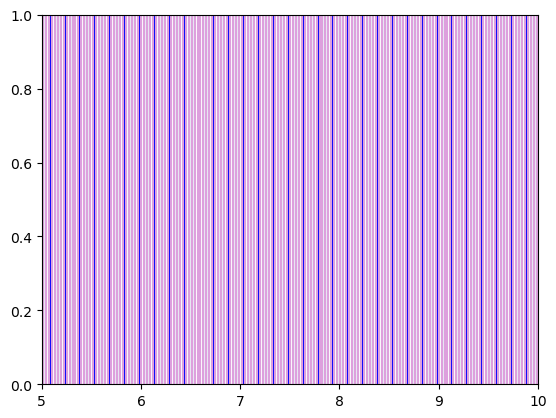

In [ ]:
for i, z in enumerate(zintegs):
    [plt.axvline(zi, color=colors[i]) for zi in z]

plt.xlim(5.0, 10.0)

In [ ]:
deltas = [dz, dz / 2., dz / 5.]

sn = '15060'
    
print("Here we go!!!")

path = '/Users/emcbride/sims'
Pdd_fn = '/Users/emcbride/kSZ/data/Pdd.npy'
errs_fn = '/Users/emcbride/kSZ/data/EMMA/EMMA_frac_errs.npz'

#data_dir = '/data/cluster/emc-brid'
#home_dir = '/home/emc-brid'
home_dir = '/Users/emcbride'
base_dir = f'{home_dir}/Datasets/LoReLi'
# home_dir = '/jet/home/emcbride'

spectra_path = 'ps_ee'
ion_path = 'metadata/ion_histories_full.npz'
Pee_path = 'spectra/Pee'
kSZ_path = 'spectra/kSZ'
fits_path = 'inference/lklhd/lklhd_files'
params_path = f'metadata/param_files'
redshift_file = f'metadata/redshift_list.dat'


ells = np.arange(0, 15000, 500)
ells[0] = 100  


sim = Cat(sn, skip_early=True,
                        base_dir=base_dir,
                        path_spectra=spectra_path,
                        path_redshifts=redshift_file,
                        LoReLi_format=True,
                        verbose=True)
    


import alfred.utils as utils
print('smoothing Pee...')
k, Pee = utils.smooth_Pee(sim)


Here we go!!!
Loading sim number 15060...
Loading the follow spectra from:
	Pee: /Users/emcbride/Datasets/LoReLi/ps_ee/simu15060/postprocessing/cubes/ps_dtb

Loading precalculated spectra (LoReLi format). If you would like fresh spectra, rerun with reinitialise_spectra=True

Fetching redshifts from:
	 /Users/emcbride/Datasets/LoReLi/metadata/redshift_list.dat
Fetching ionisation history from:
	 /Users/emcbride/Datasets/LoReLi/metadata/ion_histories_full.npz

Simulation 15060 loaded and ready for science!!

smoothing Pee...


In [ ]:
from scipy.interpolate import CubicSpline
import alfred.analyse

Pdd = np.load(Pdd_fn)
errs = np.load(errs_fn)
EMMA_k = errs['k']
frac_err_EMMA = errs['err']
err_spline  = CubicSpline(EMMA_k, frac_err_EMMA)

k0 = 3
kf = 18
krange = (k0, kf)

z0 = np.where(sim.xe > .01)[0][0]
zf = np.where(sim.xe > .9)[0][0] + 1
zrange = (z0, zf)

z_inter = np.linspace(5,25, 100)
Pdd_spline = CubicSpline(z_inter, Pdd[:,k0:kf])
Pdd_inter = Pdd_spline(sim.z[z0:zf])

truths = [modelparams_Gorce2022['alpha0'], modelparams_Gorce2022['kappa']]
priors =[(modelparams_Gorce2022['alpha0'] * .1, modelparams_Gorce2022['alpha0'] * 2.0),
            (0, modelparams_Gorce2022['kappa'] * 5.0),
            (modelparams_Gorce2022['k_f'] * .25, modelparams_Gorce2022['k_f'] * 5.0),
            (modelparams_Gorce2022['g'] * .25, modelparams_Gorce2022['g'] * 5.0)]

fit = alfred.analyse.Fit(zrange, krange, modelparams_Gorce2022, sim, priors,
                                frac_err=err_spline(sim.k[slice(*krange)]),
                                Pdd=Pdd_inter, initialise=False)


In [ ]:
import alfred.KSZ 
Dells_dz= []
zintegs = []
for delta in deltas:
    print(f"Now on dz={delta}...")
#for kmin in kmin_cutoffs:
    ksz = alfred.KSZ.KSZ_power(verbose=False, interpolate_xe=True, interpolate_Pee=True,
            helium_interp=True, k_data=k, Pee_data=Pee, z_data=sim.z, xe_data=sim.xe,
            xemax=.97, dz=delta)
    
    ksz.run_camb(force=True)
    ksz.init_reionisation_history()

    Dell = ksz.run_ksz(ells=ells, patchy=True, Dells=True)[:,0]
    
    Dells_dz.append(Dell)
    zintegs.append(ksz.z_integ)

Now on dz=0.15...
dz=0.15
z_EOR diff is [0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15
 0.15 0.15 0.15 0.15 0.15 0.15 0.15 0.15]

[4.55909884 4.70909884 4.85909884 5.00909884 5.15909884 5.30909884
 5.45909884 5.60909884 5.75909884 5.90909884 6.05909884 6.20909884
 6.35909884 6.50909884 6.65909884 6.80909884 6.95909884 7.10909884
 7.25909884 7.40909884 7.55909884 7.70909884 7.85909884 8.00909884
 8.15909884 8.30909884 8.45909884 8.60909884 8.75909884 8.90909884
 9.05909884 9.20909884 9.35909884 9.50909884 9.65909884 9.80909884
 9.95909884]
[0.97721932 0.86264535 0.73572756 0.61969356 0.52076392 0.43783793
 0.36835296 0.3092914  0.25855421 0.2156847  0.17858178 0.14723357
 0.12081818 0.09860674 0.08018962 0.06512342 0.0529534  0.04318551
 0.03537676 0.02915611 0.0241921  0.02020707 0.01698304 0.01435239
 0.01227755 0.01062947 0.00921702 0.00803446 0.00709444 0.00624262
 0.00554737 0.00493291 0.

/Users/emcbride/alfred/src/alfred/KSZ.py:716: RuntimeWarning: divide by zero encountered in log10
  interp = RegularGridInterpolator(fit_points, values, bounds_error=False, fill_value=np.log10(0.0))


Now on dz=0.075...
dz=0.075
z_EOR diff is [0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075
 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075
 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075
 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075
 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075
 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075 0.075
 0.075]

[4.48409884 4.55909884 4.63409884 4.70909884 4.78409884 4.85909884
 4.93409884 5.00909884 5.08409884 5.15909884 5.23409884 5.30909884
 5.38409884 5.45909884 5.53409884 5.60909884 5.68409884 5.75909884
 5.83409884 5.90909884 5.98409884 6.05909884 6.13409884 6.20909884
 6.28409884 6.35909884 6.43409884 6.50909884 6.58409884 6.65909884
 6.73409884 6.80909884 6.88409884 6.95909884 7.03409884 7.10909884
 7.18409884 7.25909884 7.33409884 7.40909884 7.48409884 7.55909884
 7.63409884 7.70909884 7.78409884 7.859098

In [ ]:
import os
import re

directory = f"{base_dir}/cuts"
pattern = re.compile(r".*\d{5}.*\.npz$")  # matches exact 5-digit numbers

fns = []
for filename in os.listdir(directory):
    if pattern.search(filename):
        fns.append(filename)

fns

['simu10539_cuts.npz',
 'simu10059_cuts.npz',
 'simu11933_cuts.npz',
 'simu14107_cuts.npz',
 'simu13646_cuts.npz',
 'simu15060_cuts.npz',
 'simu10528_cuts.npz',
 'simu12286_cuts.npz',
 'simu10835_cuts.npz',
 'simu10245_cuts.npz',
 'simu15042_cuts.npz',
 'simu12327_cuts.npz',
 'simu17099_cuts.npz',
 'simu10505_cuts.npz',
 'simu13873_cuts.npz',
 'simu11501_cuts.npz',
 'simu10324_cuts.npz',
 'simu12792_cuts.npz',
 'simu11174_cuts.npz',
 'simu12039_cuts.npz']

In [ ]:
kSZ['kmin']

array([0.01005388, 0.96559387, 1.20571112, 1.11329691, 0.99076377,
       0.88519525, 0.79800277, 0.72540703, 0.66490239, 0.6163785 ,
       0.573614  , 0.53824523, 0.50675576, 0.47935835, 0.45600562,
       0.43458666, 0.41539942, 0.39853243, 0.38349918, 0.36936923,
       0.35657103, 0.34498131, 0.33457253, 0.32489082, 0.31574394,
       0.30737213, 0.29962798, 0.2925095 , 0.28597557, 0.27978653])

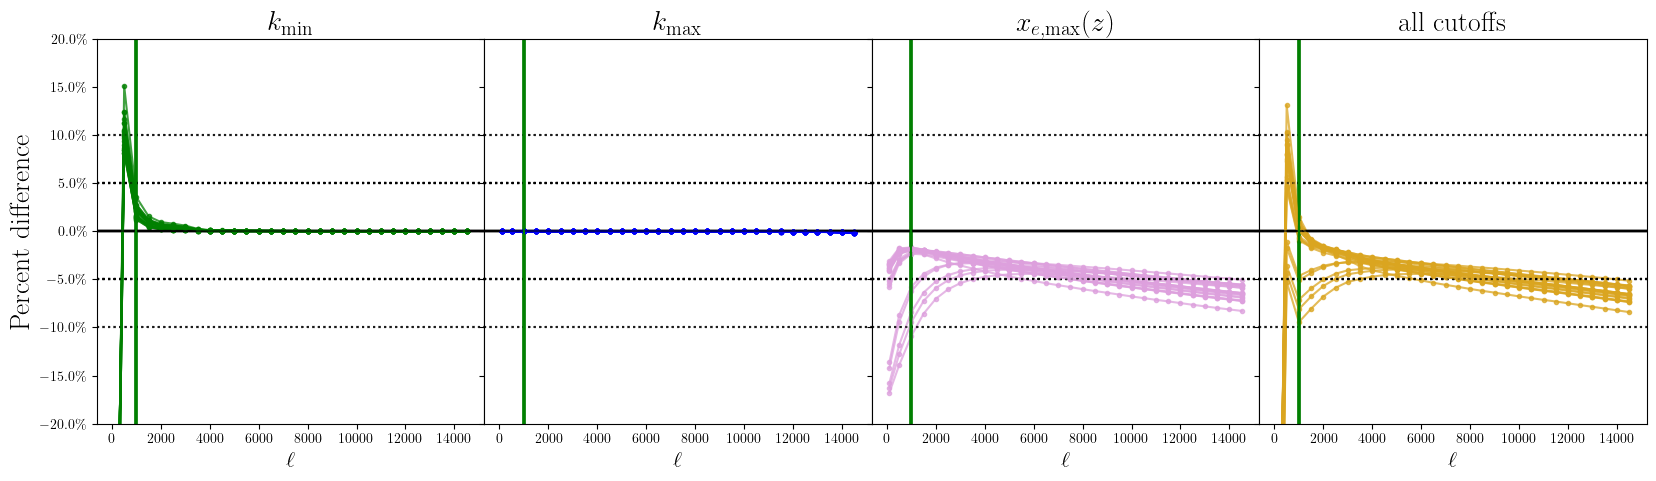

In [322]:
from matplotlib.ticker import PercentFormatter

cuts = ['uncut',  'kmin', 'kmax', 'xemax', 'cut']
labels = [r'$k_{\mathrm{min}}$', r'$k_{\mathrm{max}}$', r'$x_{e,\mathrm{max}} (z)$', 'all cutoffs']

fig, axes = plt.subplots(1,len(cuts[1:]), sharex=True, sharey=True, figsize=(20,5))
fig.subplots_adjust(wspace=0.0)

for fn in fns:
    kSZ = np.load(f"{base_dir}/cuts/{fn}", allow_pickle=True)


    for i, ax in enumerate(axes):

        ax.plot(ells, (kSZ[cuts[i+1]] - kSZ['uncut']) / kSZ['uncut'], color=colors[i], alpha=.75, marker='.', label=fn)

        ax.axhline(0.0, color='black', alpha=.5)

        ax.axhline(-.1, color='black', alpha=.1, ls=":")
        ax.axhline(.1, color='black', alpha=.1, ls=":")

        ax.axhline(-.05, color='black', alpha=.25, ls=":")
        ax.axhline(.05, color='black', alpha=.25, ls=":")

        ax.axvline(1000, color='green')
        ax.axvline(1000, color='green')

        ax.set_xlabel(r'$\ell$', fontsize=16)
        ax.set_title(f"{labels[i]}", fontsize=20)
#plt.legend()
        ax.set_ylim(-.2,.2)
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1)) 

axes[0].set_ylabel('Percent difference', fontsize=20)

fig.savefig('cuts.pdf')

In [ ]:
k_res[1]

2.7170531058073886

0.021226977389120223
cutoff at 0.022272727272727274 vs 1e-06
1.5
cutoff at 1.526315789473684 vs 10000.0
0.00416667
cutoff at 0.004166666666666667 vs 0.0


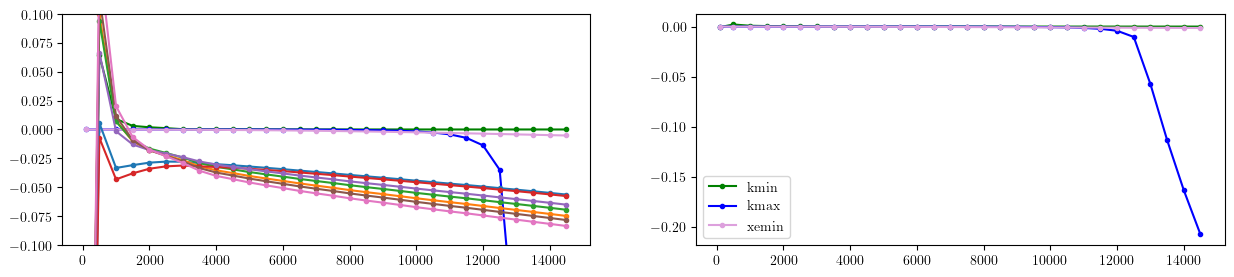

In [ ]:
cuts = [kmin_cuts, kmax_cuts, xemin_cuts, xemax_cuts]
vals = [k_res[0], 1.5, 0.00416667, .97]
lab = ['kmin', 'kmax', 'xemin', 'xemax']

fig, ax = plt.subplots(1,2, figsize=(15,3))

for i, c in enumerate(cuts[:-1]):
    Dells = c['Dells']
    cuts = c['cuts']

    print(vals[i])

    if i % 2 == 0:
        j = 0
    elif i % 2 == 1:
        j = -1

    index = np.argmin(np.abs(cuts - vals[i]))
    print(f"cutoff at {cuts[index]} vs {cuts[j]}")

    ax[0].plot(ells, ((Dells[index] - Dells[j]) / Dells[j]), label=lab[i], marker='.', color=colors[i])
    ax[1].plot(ells, (Dells[index] - Dells[j]), label=lab[i], marker='.', color=colors[i])

for fn in fns:
    kSZ = np.load(f"{base_dir}/cuts/{fn}", allow_pickle=True)

    ax[0].plot(ells, (kSZ['cut'] - kSZ['uncut']) / kSZ['uncut'], marker='.')

#plt.xlim(500, 8000)
ax[0].set_ylim(-.1,.1)
plt.legend()

In [ ]:
k_res[0]

0.021226977389120223

In [ ]:
np.arange(ksz.find_zpiv(), 10.0, step=dz)

array([4.40909884, 4.55909884, 4.70909884, 4.85909884, 5.00909884,
       5.15909884, 5.30909884, 5.45909884, 5.60909884, 5.75909884,
       5.90909884, 6.05909884, 6.20909884, 6.35909884, 6.50909884,
       6.65909884, 6.80909884, 6.95909884, 7.10909884, 7.25909884,
       7.40909884, 7.55909884, 7.70909884, 7.85909884, 8.00909884,
       8.15909884, 8.30909884, 8.45909884, 8.60909884, 8.75909884,
       8.90909884, 9.05909884, 9.20909884, 9.35909884, 9.50909884,
       9.65909884, 9.80909884, 9.95909884])

In [ ]:
zpiv = ksz.find_zpiv()
z_pre =  np.logspace(np.log10(z_min), np.log10(zpiv),
    int((np.log10(zpiv) - np.log10(z_min)) / dlogz) + 1)

z_EOR = np.arange(zpiv + dz, 10.0, step=dz)
z_post = np.arange(10, z_max + 0.5, step=0.5)

z_integ = np.concatenate((z_pre, z_EOR, z_post))


In [ ]:
ksz.xe(ksz.find_zpiv()), ksz.xe_spline(ksz.find_zpiv()), ksz.find_zpiv()

here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
True
here2
1.0817405673349607
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0


(array(1.0510521), array(0.97), 4.409098837209303)

here
True
here2
1.0817405673349607


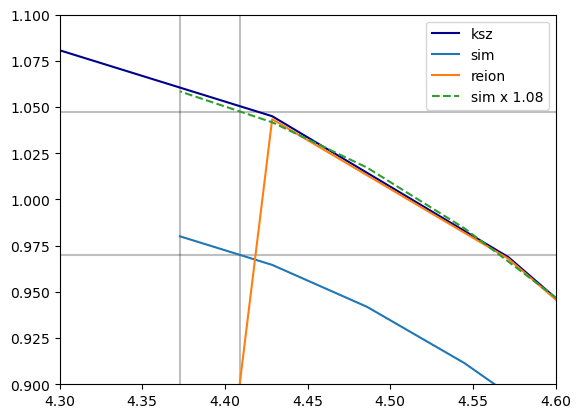

In [ ]:
plt.axvline(4.409098837209303, color='black', alpha=.25)
plt.axvline(sim.z.min(), color='black', alpha=.25)

plt.axhline(.97, color='black', alpha=.25)
plt.axhline(1.08 * .97, color='black', alpha=.25)

xe = ksz.xe(z)

plt.plot(z, xe, color='darkblue', label='ksz')
plt.plot(sim.z, sim.xe, label='sim')
plt.plot(z, ksz.xe_reion, label='reion')


plt.plot(sim.z, 1.08 * sim.xe, ls='--', label='sim x 1.08')




plt.xlim(4.3, 4.6)
plt.ylim(.9,1.1)
plt.legend()

In [ ]:
print('Redshifts are:')
print(z)
print()

print(f"Early ends at {ksz.z_data.max()}")
print(ksz.xe_early)
print()

print(f"Reion from {ksz.z_data.min()} to {ksz.z_data.max()}")
print(ksz.xe_reion)
print()

print(f"Late")
print(ksz.xe_late)
print()

print(ksz.xe_He)
print()

Redshifts are:
[ 3.          3.14285714  3.28571429  3.42857143  3.57142857  3.71428571
  3.85714286  4.          4.14285714  4.28571429  4.42857143  4.57142857
  4.71428571  4.85714286  5.          5.14285714  5.28571429  5.42857143
  5.57142857  5.71428571  5.85714286  6.          6.14285714  6.28571429
  6.42857143  6.57142857  6.71428571  6.85714286  7.          7.14285714
  7.28571429  7.42857143  7.57142857  7.71428571  7.85714286  8.
  8.14285714  8.28571429  8.42857143  8.57142857  8.71428571  8.85714286
  9.          9.14285714  9.28571429  9.42857143  9.57142857  9.71428571
  9.85714286 10.        ]

Early ends at 18.795
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]

Reion from 4.3728 to 18.795
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         1.04344471 0.96794
 0.85784361 0.73712865 0.62617375 0.53079526 0.45014085

In [ ]:
ksz.find_zpiv()

here
1.0
here
1.0
here
1.0
here
1.0
here
1.0
here
1.0
here
1.0
here
1.0
here
1.0
here
1.0


4.409098837209303

In [ ]:
zpiv = ksz.find_zpiv()

1.0
early 0.0
reion 0.0
late 1.0
He 0
1.0
early 0.0
reion 0.96459
late 0.0
He 0
1.0
early 0.0
reion 0.0
late 1.0
He 0
1.0
early 0.0
reion 0.9673654384515687
late 0.0
He 0
1.0
early 0.0
reion 0.9697873139940252
late 0.0
He 0
1.0
early 0.0
reion 0.9699902002012757
late 0.0
He 0
1.0
early 0.0
reion 0.9699999603593609
late 0.0
He 0
1.0
early 0.0
reion 0.9699999999925594
late 0.0
He 0
1.0
early 0.0
reion 0.9699999999999999
late 0.0
He 0
1.0
early 0.0
reion 0.9700000000002778
late 0.0
He 0


In [ ]:
zpiv

4.409098837209303

In [ ]:
ksz.xe_spline(zpiv), ksz.xe(zpiv)

1.0817405673349607
early 0.0
reion 1.0492883503149117
late 0.0
He 0.0017637483296882278


(array(0.97), array(1.0510521))

In [ ]:
ksz.xe_early + ksz.xe_reion + ksz.xe_late + ksz.xe_He

np.float64(1.0510520986446)

In [ ]:
ksz.xe_early, ksz.xe_reion, ksz.xe_late, ksz.xe_He

(array(0.),
 np.float64(1.0492883503149117),
 array(0.),
 np.float64(0.0017637483296882278))

In [ ]:
.97 * 1.08 + ksz.xe_He

np.float64(1.0493637483296883)

In [ ]:
ksz.xe(30)

1.0817405673349607
early 0.0001
reion 0.0
late 0.0
He 0.0


array(0.0001)

In [ ]:
z = np.linspace(3,10)



here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
False
1.0
here
True
here2
1.0817405673349607


array(1.0510521)